# Week 4 Day 4 — Factor Scores

`scores = pca.transform(X)` projects each day's 8-dimensional yield change vector
onto the PC axes. `score_1[t]` is how much the level factor moved on day `t` in bp.

Two validations:
1. **Cumulative scores over time** — should look like the history of rates/slope/curvature
2. **Proxy regression** — simple observables (avg(2Y,10Y), 10Y-2Y, 2·5Y-2Y-10Y)
   should have R² ≥ 0.98 against the corresponding PC score

In [1]:
import sys
sys.path.insert(0, '../src')

import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

In [2]:
from termstructure.pca.decomposition import compute_factor_scores

scores = compute_factor_scores().set_index('date')
print(f'Shape: {scores.shape}   {scores.index[0].date()} → {scores.index[-1].date()}')
scores.head()

Shape: (10093, 8)   1985-11-26 → 2026-05-01


,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8
date,,,,,,,,
1985-11-26,-3.242511,-4.701559,-4.850662,-0.321679,1.208816,0.179910,0.061356,0.009989
1985-11-27,-6.694500,-2.125688,2.837955,-0.998228,-1.531074,-0.166763,-0.088579,-0.006016
1985-11-29,-12.011678,0.847529,0.495599,-1.468233,-2.352149,0.015785,-0.084866,0.017628
1985-12-02,17.804273,7.033799,-1.370279,2.852433,0.433116,0.155330,0.082493,0.021771
1985-12-03,-1.789177,-13.132844,-7.200217,-0.873048,3.300849,0.190076,0.139165,0.001845


## 1. Cumulative factor scores over time

Cumulative sum of each score = total accumulated movement of that factor since the
first date. Expected shapes:
- **PC1 (level):** large decline from 1982 peak (~−1500bp), then sharp rise in 2022
- **PC2 (slope):** oscillates with the business cycle; deeply negative during 2006–2007 inversion
- **PC3 (curvature):** noisier, harder to read by eye

Gray shading marks NBER recessions.

In [3]:
# Download NBER recession indicator from FRED
r = requests.get('https://fred.stlouisfed.org/graph/fredgraph.csv?id=USREC', timeout=10)
usrec = pd.read_csv(io.StringIO(r.text))
usrec.columns = ['date', 'recession']
usrec['date'] = pd.to_datetime(usrec['date'])
usrec = usrec.set_index('date')

def shade_recessions(ax, usrec):
    in_rec, start = False, None
    for date, row in usrec.iterrows():
        if row['recession'] == 1 and not in_rec:
            in_rec, start = True, date
        elif row['recession'] == 0 and in_rec:
            in_rec = False
            ax.axvspan(start, date, alpha=0.15, color='gray', zorder=0)
    if in_rec:
        ax.axvspan(start, usrec.index[-1], alpha=0.15, color='gray', zorder=0)

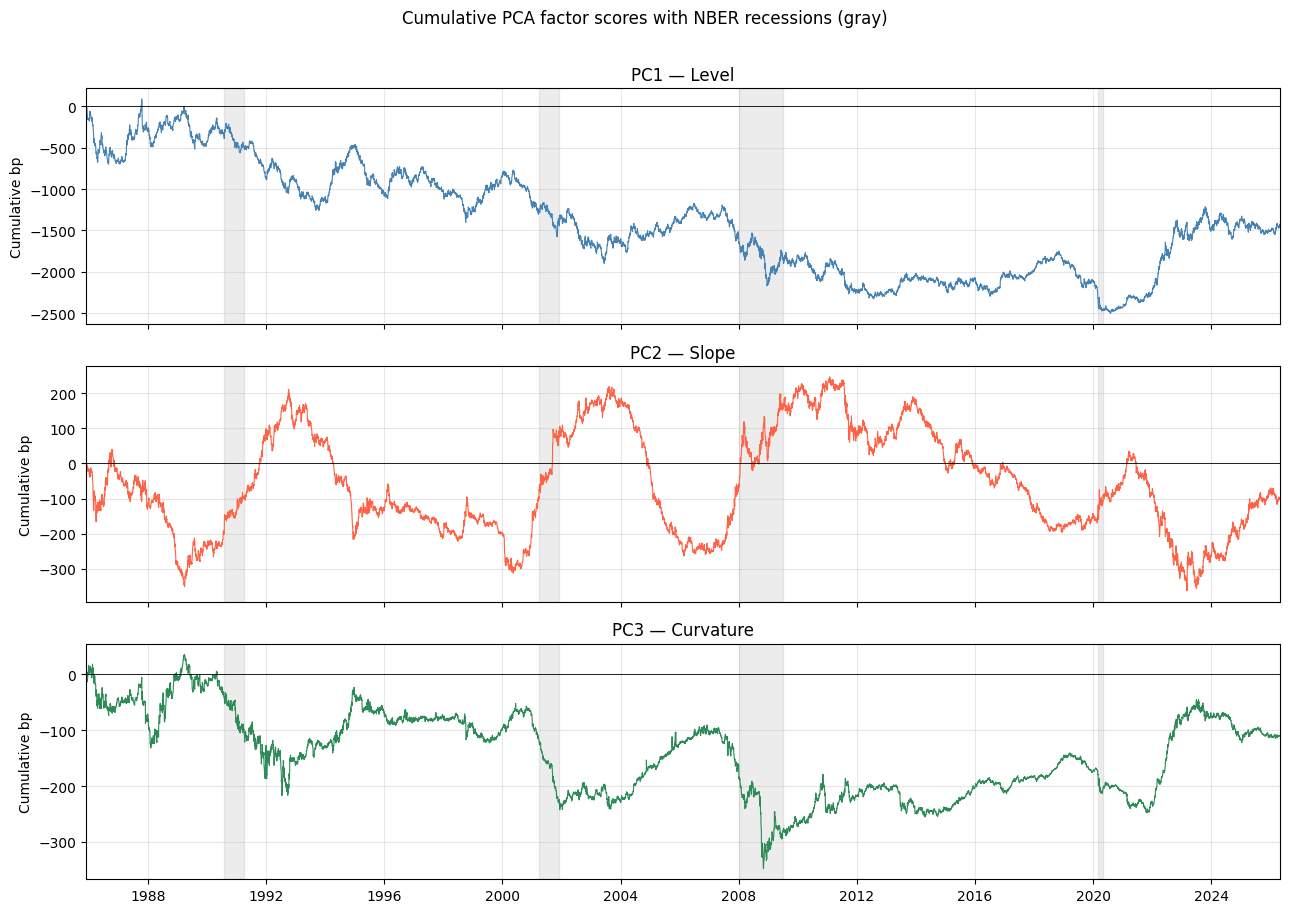

In [4]:
cum = scores[['score_1', 'score_2', 'score_3']].cumsum()
labels  = ['PC1 — Level', 'PC2 — Slope', 'PC3 — Curvature']
colors  = ['steelblue', 'tomato', 'seagreen']

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, col, label, color in zip(axes, cum.columns, labels, colors):
    ax.plot(cum.index, cum[col], lw=0.8, color=color)
    ax.axhline(0, color='black', lw=0.6)
    ax.set_ylabel('Cumulative bp')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    shade_recessions(ax, usrec)

axes[-1].set_xlim(scores.index[0], scores.index[-1])

plt.suptitle('Cumulative PCA factor scores with NBER recessions (gray)', y=1.01)
plt.tight_layout()
plt.savefig('data/week4_day4_cumscores.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Proxy regression

Regresses the **cumulative** factor score against the **level** of the corresponding
observable proxy — both from `zero_panel.parquet`.

| Factor | Cumulative score | Proxy level |
|--------|-----------------|-------------|
| PC1 | Σ score_1 (total level bp accumulated) | avg(y_2, y_10) in bp |
| PC2 | Σ score_2 (total slope bp accumulated) | y_10 − y_2 in bp |
| PC3 | Σ score_3 (total curvature bp accumulated) | 2·y_5 − y_2 − y_10 in bp |

The cumulative score tracks *how much that factor has moved* since the start date.
The proxy level tracks *where that observable is* on the same day. Both are
non-stationary, integrated series — they drift together if the PC captures
the right economic factor. R² ≥ 0.98 validates the level/slope/curvature
interpretation.

In [5]:
panel_lev = pd.read_parquet('../data/processed/zero_panel.parquet')
panel_lev['date'] = pd.to_datetime(panel_lev['date'])
panel_lev = panel_lev.sort_values('date').set_index('date')

cum    = scores[['score_1', 'score_2', 'score_3']].cumsum()
common = cum.index.intersection(panel_lev.index)

# --- PC1 and PC2: non-stationary (trending) factors ---
# Cumulative score vs proxy level — both are I(1), so they cointegrate.
# Proxy choice follows the empirical PC loading vectors:
#   PC2 loading runs from -0.40 at 1Y to +0.59 at 30Y → 30Y-2Y captures the full range.
level_level = (panel_lev.loc[common, 'y_2']  + panel_lev.loc[common, 'y_10']) / 2 * 10_000
slope_level = (panel_lev.loc[common, 'y_30'] - panel_lev.loc[common, 'y_2'])         * 10_000

# --- PC3: curvature is stationary (mean-reverting) ---
# Cumsum of a stationary process is non-stationary while the proxy level
# mean-reverts → no cointegration → cumulative R² is near zero.
# Fix: regress daily score_3 against daily butterfly change.
# PC3 loading: -0.42 at 10Y (deepest negative), +0.70 at 30Y (strongest positive)
# → 2·dy_10 - dy_2 - dy_30 is the best simple observable proxy.
curv_daily_proxy = (2 * panel_lev.loc[common, 'dy_10']
                    - panel_lev.loc[common, 'dy_2']
                    - panel_lev.loc[common, 'dy_30'])

rows = []
for proxy, x_col, use_cum, name, target in [
    (level_level,      'score_1', True,  'Level: avg(2Y,10Y)',   0.98),
    (slope_level,      'score_2', True,  'Slope: 30Y−2Y',        0.98),
    (curv_daily_proxy, 'score_3', False, 'Curvature: 2·dy10−dy2−dy30 (daily)', 0.70),
]:
    x = (cum.loc[common, x_col] if use_cum else scores.loc[common, x_col]).values
    y = proxy.values
    _, _, r, _, _ = stats.linregress(x, y)
    r2 = r ** 2
    method = 'cumul.' if use_cum else 'daily '
    rows.append({
        'proxy':   name,
        'PC':      x_col.replace('score_', 'PC'),
        'method':  method,
        'R²':      round(r2, 4),
        'pass':    '✓' if r2 >= target else f'✗  (target >= {target})',
    })

pd.DataFrame(rows).set_index('proxy')

,PC,method,R²,pass
proxy,,,,
"Level: avg(2Y,10Y)",PC1,cumul.,0.9973,✓
Slope: 30Y−2Y,PC2,cumul.,0.9912,✓
Curvature: 2·dy10−dy2−dy30 (daily),PC3,daily,0.7838,✓


## 3. Time series overlay

Each panel overlays the cumulative factor score (left axis) against its proxy level
(right axis). If the two lines track each other closely, the factor interpretation
is confirmed.

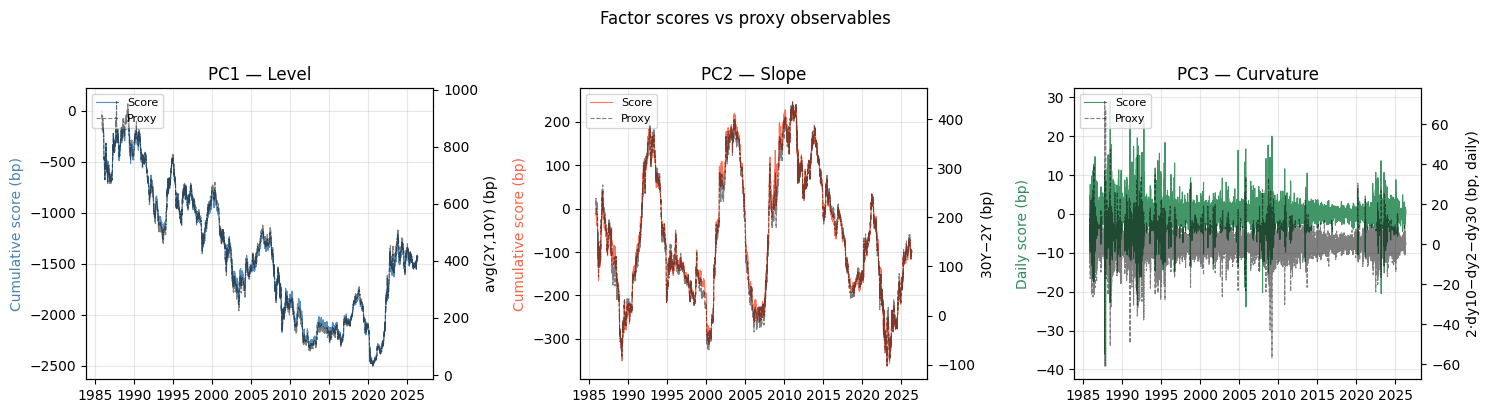

In [6]:
proxies    = [level_level, slope_level, curv_daily_proxy]
cum_cols   = ['score_1', 'score_2', 'score_3']
proxy_lbls = ['avg(2Y,10Y) (bp)', '30Y−2Y (bp)', '2·dy10−dy2−dy30 (bp, daily)']
titles     = ['PC1 — Level', 'PC2 — Slope', 'PC3 — Curvature']
colors     = ['steelblue', 'tomato', 'seagreen']
use_cum    = [True, True, False]   # PC3 uses daily score, not cumulative

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, proxy, cc, use_c, pl, title, color in zip(
        axes, proxies, cum_cols, use_cum, proxy_lbls, titles, colors):
    x_series = cum.loc[common, cc] if use_c else scores.loc[common, cc]
    ax2 = ax.twinx()
    ax.plot(common, x_series, lw=0.8, color=color, alpha=0.9, label='Score')
    ax2.plot(common, proxy, lw=0.8, color='black', alpha=0.5, linestyle='--', label='Proxy')
    ax.set_title(title)
    xlabel = 'Cumulative score (bp)' if use_c else 'Daily score (bp)'
    ax.set_ylabel(xlabel, color=color)
    ax2.set_ylabel(pl, color='black')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle('Factor scores vs proxy observables', y=1.02)
plt.tight_layout()
plt.savefig('data/week4_day4_overlay.png', dpi=150, bbox_inches='tight')
plt.show()